# NLP Data Preparation and EDA

## Goal

This notebook prepares the NLP data for the next parts of the project.

It does these steps:

- Load the train, test, and product files
- Check the data
- Clean the main columns
- Check the class distribution
- Create word clouds
- Check review length
- Create one shared train and validation split
- Save the final files

## 1. Install and Import Libraries

Most libraries are already available in Google Colab. We install `wordcloud` because we need it for the EDA.

In [1]:
!pip install wordcloud -q

In [4]:
import os
import random
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from wordcloud import WordCloud, STOPWORDS

## 2. Set the Random Seed

We use one fixed seed so all team members get the same split.

In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

## 3. Connect Google Drive

In [6]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 4. Set File Paths

Change these paths if your file names or folders are different.

In [7]:
PROJECT_PATH = "/content/drive/MyDrive/AI_Project2"

TRAIN_PATH = PROJECT_PATH + "/data/nlp/train_data.csv"
TEST_PATH = PROJECT_PATH + "/data/nlp/test_data.csv"
PRODUCTS_PATH = PROJECT_PATH + "/data/nlp/title_brand.csv"

OUTPUT_PATH = PROJECT_PATH + "/outputs/nlp"

os.makedirs(OUTPUT_PATH, exist_ok=True)

## 5. Load the Data

In [8]:
train_df = pd.read_csv(TRAIN_PATH, low_memory=False)
test_df = pd.read_csv(TEST_PATH, low_memory=False)
products_df = pd.read_csv(PRODUCTS_PATH, low_memory=False)

In [9]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Products shape:", products_df.shape)

Train shape: (838944, 11)
Test shape: (20000, 10)
Products shape: (786445, 3)


In [ ]:
display(train_df.head())
display(test_df.head())
display(products_df.head())

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime
0,2,NaN,False,2016-11-11,A2OSUEZJIN7BI,0511189877,NaN,Chris,I have an older URC-WR7 remote and thought thi...,Cannot Learn,1478822400
1,5,NaN,True,2016-06-06,A2NETQRG6JHIG7,0511189877,NaN,Qrysta White,First time I've EVER had a remote that needed ...,zero programming needed! Miracle!?,1465171200
2,4,NaN,True,2016-03-10,A12JHGROAX49G7,0511189877,NaN,Linwood,Got them and only 2 of them worked. company ca...,Works Good and programs easy.,1457568000
3,5,NaN,True,2016-01-14,A1KV65E2TMMG6F,0511189877,NaN,Dane Williams,I got tired of the remote being on the wrong s...,Same as TWC remote,1452729600
4,5,NaN,True,2016-10-20,A280POPEWI0NSA,0594459451,NaN,Kristina H.,After purchasing cheap cords from another webs...,Good Quality Cord,1476921600


,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime
0,NaN,True,2018-06-04,A20GGWE66JW9X2,B006Z394GM,{'Color:': ' FPS01-C'},Brian C Toner,The name and description of this device are mi...,The prize for most useless invention of all ti...,1528070400
1,NaN,True,2018-02-18,ARYJWXHEYHG9M,B005BE058W,"{'Size:': ' 1000W', 'Style:': ' G2'}",Snake,One of the molex connectors on the power suppl...,MELTED MOLEX CONNECTOR,1518912000
2,NaN,True,2018-01-20,A10LHZ7WFZ7HLL,B01DA0YCNC,NaN,Amazon Customer,Remote constantly disconnects/ Roku player fre...,Bricked on the regular,1516406400
3,NaN,True,2018-06-25,A11VN8EOHNLP72,B00FBJ4KYC,NaN,Jeremy Bray,I purchased this 4 year protection plan for a ...,DO NOT BUY!!!,1529884800
4,3.0,True,2016-08-17,A194Y8P8TVT7P9,B00P7G82TS,NaN,Mark,I bought one of these and have regretted it ev...,Nightmare - don't buy,1471392000


,asin,title,brand
0,0011300000,Genuine Geovision 1 Channel 3rd Party NVR IP S...,GeoVision
1,0043396828,"Books ""Handbook of Astronomical Image Processi...",33 Books Co.
2,0060009810,One Hot Summer,Visit Amazon's Carolina Garcia Aguilera Page
3,0060219602,Hurray for Hattie Rabbit: Story and pictures (...,Visit Amazon's Dick Gackenbach Page
4,0060786817,sex.lies.murder.fame.: A Novel,Visit Amazon's Lolita Files Page


## 6. Check the Data

We check the column names, data types, missing values, and duplicate rows.

In [ ]:
print("Train columns:")
print(train_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

print("\nProducts columns:")
print(products_df.columns.tolist())

Train columns:
['overall', 'vote', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime']

Test columns:
['vote', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime']

Products columns:
['asin', 'title', 'brand']


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838944 entries, 0 to 838943
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   overall         838944 non-null  int64 
 1   vote            191468 non-null  object
 2   verified        838944 non-null  bool  
 3   reviewTime      838944 non-null  object
 4   reviewerID      838944 non-null  object
 5   asin            838944 non-null  object
 6   style           490613 non-null  object
 7   reviewerName    838717 non-null  object
 8   reviewText      838944 non-null  object
 9   summary         838868 non-null  object
 10  unixReviewTime  838944 non-null  int64 
dtypes: bool(1), int64(2), object(8)
memory usage: 64.8+ MB


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   vote            4933 non-null   float64
 1   verified        20000 non-null  bool   
 2   reviewTime      20000 non-null  object 
 3   reviewerID      20000 non-null  object 
 4   asin            20000 non-null  object 
 5   style           11504 non-null  object 
 6   reviewerName    19996 non-null  object 
 7   reviewText      20000 non-null  object 
 8   summary         19998 non-null  object 
 9   unixReviewTime  20000 non-null  int64  
dtypes: bool(1), float64(1), int64(1), object(7)
memory usage: 1.4+ MB


In [ ]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 786445 entries, 0 to 786444
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   asin    786445 non-null  object
 1   title   786426 non-null  object
 2   brand   780947 non-null  object
dtypes: object(3)
memory usage: 18.0+ MB


In [ ]:
train_missing = pd.DataFrame({
    "missing_count": train_df.isnull().sum(),
    "missing_percent": (train_df.isnull().sum() / len(train_df) * 100).round(2)
})

test_missing = pd.DataFrame({
    "missing_count": test_df.isnull().sum(),
    "missing_percent": (test_df.isnull().sum() / len(test_df) * 100).round(2)
})

products_missing = pd.DataFrame({
    "missing_count": products_df.isnull().sum(),
    "missing_percent": (products_df.isnull().sum() / len(products_df) * 100).round(2)
})

print("Train missing values:")
display(train_missing[train_missing["missing_count"] > 0])

print("Test missing values:")
display(test_missing[test_missing["missing_count"] > 0])

print("Products missing values:")
display(products_missing[products_missing["missing_count"] > 0])

Train missing values:


,missing_count,missing_percent
vote,647476,77.18
style,348331,41.52
reviewerName,227,0.03
summary,76,0.01


Test missing values:


,missing_count,missing_percent
vote,15067,75.33
style,8496,42.48
reviewerName,4,0.02
summary,2,0.01


Products missing values:


,missing_count,missing_percent
title,19,0.0
brand,5498,0.7


The main columns needed for sentiment modeling, including `reviewText`, `overall`, and `asin`, do not have missing values in the training data.

The `vote` and `style` columns contain many missing values, but they are not required for the main sentiment models. For this reason, we keep these missing values and do not remove their rows.

A small number of values are missing from `reviewerName` and `summary`. These columns are also not required for the main model, so their rows are kept.



In [ ]:
print("Duplicate rows in train:", train_df.duplicated().sum())
print("Duplicate rows in test:", test_df.duplicated().sum())
print("Duplicate rows in products:", products_df.duplicated().sum())

Duplicate rows in train: 8327
Duplicate rows in test: 3
Duplicate rows in products: 30368


## 7. Basic Data Cleaning

We keep the cleaning simple.

- Remove duplicate rows from the train data
- Remove train rows without review text or rating which we don't have
- Keep ratings from 1 to 5
- Keep the raw text
- Create a simple clean text
- Do not remove stop words from the model data
- Do not remove any row from the test data

In [10]:
train_df = train_df.drop_duplicates().copy()

In [11]:
train_df = train_df[train_df["overall"].between(1, 5)].copy()

We keep the original text in `reviewText_raw`.

The clean text only removes HTML tags and extra spaces.

In [12]:
train_df["reviewText_raw"] = train_df["reviewText"].astype(str)
test_df["reviewText_raw"] = test_df["reviewText"].fillna("").astype(str)

In [13]:
train_df["reviewText_clean"] = train_df["reviewText_raw"].str.replace(
    r"<[^>]+>",
    " ",
    regex=True
)

train_df["reviewText_clean"] = train_df["reviewText_clean"].str.replace(
    r"\s+",
    " ",
    regex=True
).str.strip()

In [14]:
test_df["reviewText_clean"] = test_df["reviewText_raw"].str.replace(
    r"<[^>]+>",
    " ",
    regex=True
)

test_df["reviewText_clean"] = test_df["reviewText_clean"].str.replace(
    r"\s+",
    " ",
    regex=True
).str.strip()

In [15]:
train_df = train_df[train_df["reviewText_clean"] != ""].copy()

## 8. Add Row IDs

`row_id` helps us keep the original order of the data, especially for the test file.

In [16]:
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df.insert(0, "row_id", range(len(train_df)))
test_df.insert(0, "row_id", range(len(test_df)))

## 9. Merge Product Information

We merge the product table with `asin`.

This gives us product title and brand if these columns exist in the product file.

In [17]:
products_df = products_df.drop_duplicates(subset=["asin"]).copy()

In [18]:
products_small = products_df[["asin", "brand", "title"]].copy()

train_df = train_df.merge(products_small, on="asin", how="left")
test_df = test_df.merge(products_small, on="asin", how="left")

In [19]:
display(train_df.head())

,row_id,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,reviewText_raw,reviewText_clean,brand,title
0,0,2,NaN,False,2016-11-11,A2OSUEZJIN7BI,0511189877,NaN,Chris,I have an older URC-WR7 remote and thought thi...,Cannot Learn,1478822400,I have an older URC-WR7 remote and thought thi...,I have an older URC-WR7 remote and thought thi...,URC,CLIKR-5 Time Warner Cable Remote Control UR5U-...
1,1,5,NaN,True,2016-06-06,A2NETQRG6JHIG7,0511189877,NaN,Qrysta White,First time I've EVER had a remote that needed ...,zero programming needed! Miracle!?,1465171200,First time I've EVER had a remote that needed ...,First time I've EVER had a remote that needed ...,URC,CLIKR-5 Time Warner Cable Remote Control UR5U-...
2,2,4,NaN,True,2016-03-10,A12JHGROAX49G7,0511189877,NaN,Linwood,Got them and only 2 of them worked. company ca...,Works Good and programs easy.,1457568000,Got them and only 2 of them worked. company ca...,Got them and only 2 of them worked. company ca...,URC,CLIKR-5 Time Warner Cable Remote Control UR5U-...
3,3,5,NaN,True,2016-01-14,A1KV65E2TMMG6F,0511189877,NaN,Dane Williams,I got tired of the remote being on the wrong s...,Same as TWC remote,1452729600,I got tired of the remote being on the wrong s...,I got tired of the remote being on the wrong s...,URC,CLIKR-5 Time Warner Cable Remote Control UR5U-...
4,4,5,NaN,True,2016-10-20,A280POPEWI0NSA,0594459451,NaN,Kristina H.,After purchasing cheap cords from another webs...,Good Quality Cord,1476921600,After purchasing cheap cords from another webs...,After purchasing cheap cords from another webs...,Barnes &amp; Noble,Barnes &amp; Noble Nook Color Tablet USB Cable...


## 10. EDA, First Question : Class Distribution

The target column is `overall`.

We check if ratings 1 to 5 have similar numbers of samples.

In [ ]:
rating_counts = train_df["overall"].value_counts().sort_index()

rating_table = pd.DataFrame({
    "count": rating_counts,
    "percent": (rating_counts / len(train_df) * 100).round(2)
})

display(rating_table)

,count,percent
overall,,
1,82247,9.90
2,56288,6.78
3,80460,9.69
4,155141,18.68
5,456476,54.96


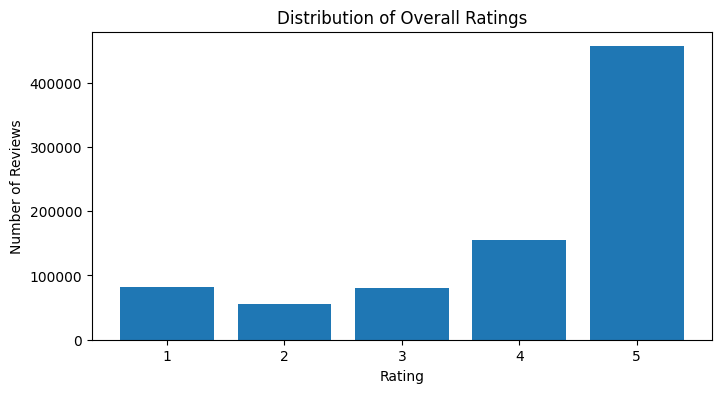

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(rating_counts.index, rating_counts.values)
plt.title("Distribution of Overall Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks([1, 2, 3, 4, 5])
plt.show()

In [ ]:
imbalance_ratio = rating_counts.max() / rating_counts.min()

print("Largest class / smallest class:", round(imbalance_ratio, 2))

Largest class / smallest class: 8.11


The dataset is imbalanced because rating 5 has many more samples than the other ratings. This may cause the model to predict the majority class more often  
We keep the original data for the shared split.
The model notebooks can use class weights on the training set.
Validation and test data must stay unchanged.

## 11. EDA, Second Question : Create Sentiment Labels

These labels are only for EDA.

- Ratings 4 and 5 are positive
- Rating 3 is neutral
- Ratings 1 and 2 are negative

The final model target is still `overall`.

In [ ]:
train_df["sentiment"] = "neutral"

train_df.loc[train_df["overall"] >= 4, "sentiment"] = "positive"
train_df.loc[train_df["overall"] <= 2, "sentiment"] = "negative"

In [ ]:
display(train_df["sentiment"].value_counts())

,count
sentiment,
positive,611617
negative,138535
neutral,80460


## 12. Word Clouds

Stop words are removed only for the word clouds.


In [ ]:
stop_words = set(STOPWORDS)

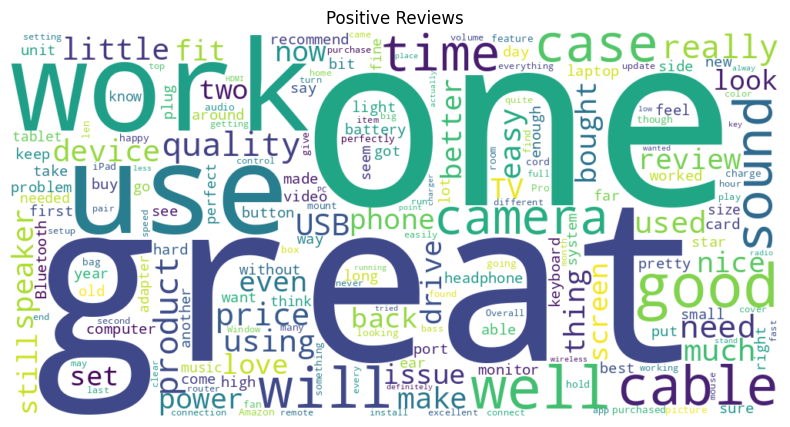

In [ ]:
positive_text = " ".join(
    train_df.loc[
        train_df["sentiment"] == "positive",
        "reviewText_clean"
    ].astype(str)
)

positive_cloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=stop_words,
    random_state=SEED,
    collocations=False
).generate(positive_text)

plt.figure(figsize=(12, 5))
plt.imshow(positive_cloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews")
plt.show()

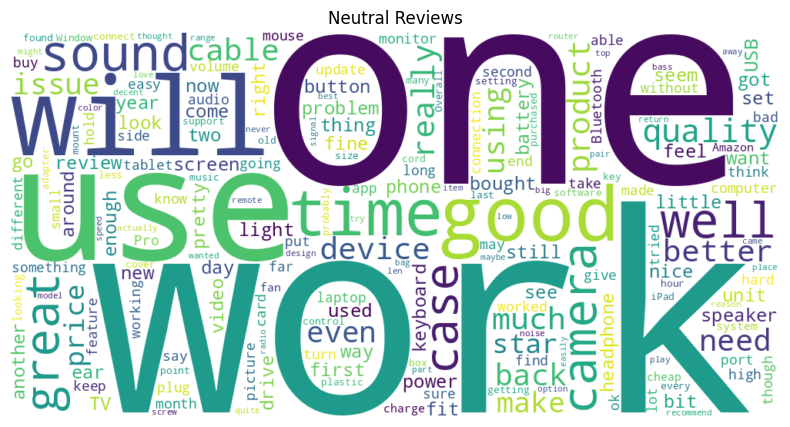

In [ ]:
neutral_text = " ".join(
    train_df.loc[
        train_df["sentiment"] == "neutral",
        "reviewText_clean"
    ].astype(str)
)

neutral_cloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=stop_words,
    random_state=SEED,
    collocations=False
).generate(neutral_text)

plt.figure(figsize=(12, 5))
plt.imshow(neutral_cloud, interpolation="bilinear")
plt.axis("off")
plt.title("Neutral Reviews")
plt.show()

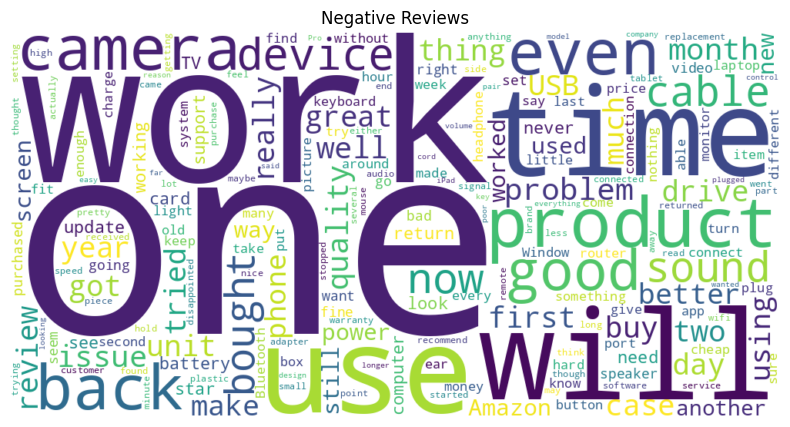

In [ ]:
negative_text = " ".join(
    train_df.loc[
        train_df["sentiment"] == "negative",
        "reviewText_clean"
    ].astype(str)
)

negative_cloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=stop_words,
    random_state=SEED,
    collocations=False
).generate(negative_text)

plt.figure(figsize=(12, 5))
plt.imshow(negative_cloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews")
plt.show()

There are many common words in the positive and negative reviews, such as use, work, product, one, time, cable, phone, and bought. These words mainly describe the product or the user experience, so they do not show sentiment by themselves.

For example, the word work can appear in both “it works well” and “it does not work.” Also, the word good may appear in a negative sentence such as “not good.”

However, in positive's word cloud these positive words "great" "well" "good" are bigger than other clouds.
but we can not see negative words in negative cloud.

This shows that a word cloud only shows word frequency and cannot understand the full meaning of a sentence. The sentiment depends on the context and the relation between words.

## Improved Word Clouds

The first word clouds contained many common words such as `product`, `use`, `one`, and `time`.

These words are common in both positive and negative reviews, but they do not show sentiment clearly.

For this reason, we add some common product-related words to the stop word list.

These extra stop words are used only for the word clouds. They are not removed from the data used by the models.

In [ ]:
stop_words = set(STOPWORDS)

custom_stop_words = {
    "product",
    "use",
    "used",
    "one",
    "time",
    "will",
    "came",
    "bought",
    "thing",
    "device",
    "amazon",
    "really",
    "much",
    "even",
    "got",
    "make",
    "way",
    "now",
    "back",
    "need",
    "work"
}

stop_words.update(custom_stop_words)

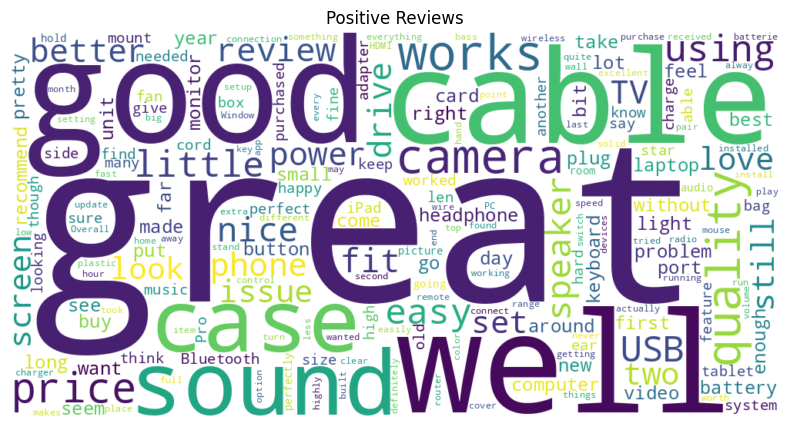

In [ ]:
positive_text = " ".join(
    train_df.loc[
        train_df["sentiment"] == "positive",
        "reviewText_clean"
    ].astype(str)
)

positive_cloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=stop_words,
    random_state=SEED,
    collocations=False
).generate(positive_text)

plt.figure(figsize=(12, 5))
plt.imshow(positive_cloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews")
plt.show()

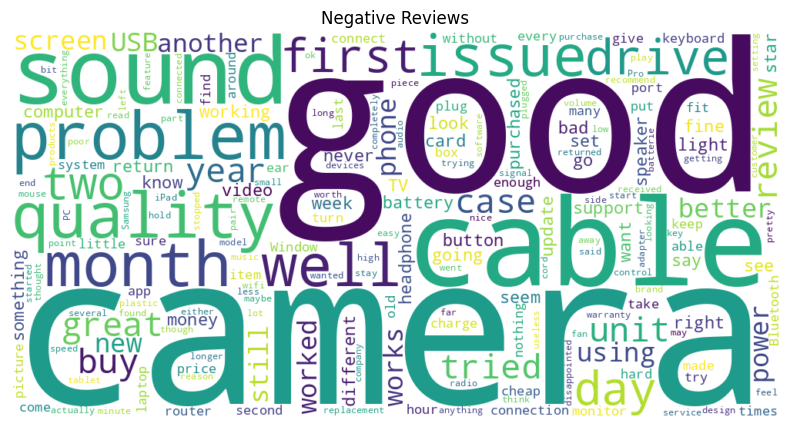

In [ ]:
negative_text = " ".join(
    train_df.loc[
        train_df["sentiment"] == "negative",
        "reviewText_clean"
    ].astype(str)
)

negative_cloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=stop_words,
    random_state=SEED,
    collocations=False
).generate(negative_text)

plt.figure(figsize=(12, 5))
plt.imshow(negative_cloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews")
plt.show()

Even after improving the stop-word list, the word clouds still contain some general words.

The improved word clouds are more useful than the first version, but they should only be used as a simple visual EDA tool.

In [ ]:
camera_negative_reviews = train_df.loc[
    (train_df["sentiment"] == "negative") &
    (train_df["reviewText_clean"].str.contains(
        r"\bcamera\b",
        case=False,
        na=False
    )),
    "reviewText_clean"
]

camera_negative_reviews.sample(10, random_state=SEED).tolist()

['Free Mini Ball Head Gift ,YONGNUO YN300 Air Ultra Thin CRI95 3200K-5500K On Camera Led Video Light continuous lighting Lamp for Canon Nikon GoPro Sony Youtube Vlog Video Shooting I bought these to power my lights listed above, 1 These take forever to charge if you are trying to do a photo shoot with LED lights you best get more then one set these take over 8 hours to charge. 2 One died 10 minutes into the shoot, the other one lasted about 45 minutes.. I contacted the company ant they are sending me another set we will see if they do any better.. No I would not buy again.. I do paid photography and need reliable batteries to keep my led lights back on.. it was embarrassing in the middle of the shoot to have to pull out and set up flashes and redo the lighting as these batteries failed on me',
 'Absolute crap! Cant format SD via the camera anymore as the new version took that away. So if you cant use your phone to control it you cant use this camera because there is no way for format t

The word camera is very frequent in the negative reviews. However, it is not a negative word by itself. It mainly shows that many reviews are about cameras or camera features.

In [ ]:
for label in ["positive", "neutral", "negative"]:
    reviews = train_df.loc[
        train_df["sentiment"] == label,
        "reviewText_clean"
    ]

    count = reviews.str.contains(
        r"\bcamera\b",
        case=False,
        na=False
    ).sum()

    percent = count / len(reviews) * 100

    print(label, "count:", count, "percent:", round(percent, 2))

positive count: 53080 percent: 8.68
neutral count: 7289 percent: 9.06
negative count: 11867 percent: 8.57


The word **camera** appears clearly in all three word clouds. However, its percentage is very similar across the sentiment groups

Therefore, `camera` is not related to negative sentiment. It mainly shows that many reviews in the dataset are about cameras or camera features.

Also, word sizes should not be compared directly across separate word clouds because each word cloud scales its words based on the frequencies inside its own sentiment group.

## 13. EDA, Fourth Question : Review Length Analysis

We check the number of characters and words in each review.

This result helps the model team choose a good input length.

In [ ]:
train_df["text_char_length"] = train_df["reviewText_clean"].str.len()
train_df["text_word_length"] = train_df["reviewText_clean"].str.split().str.len()


In [ ]:
display(
    train_df[["text_char_length", "text_word_length"]].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

,text_char_length,text_word_length
count,830612.000000,830612.000000
mean,616.932305,115.180318
std,672.947112,123.424405
min,6.000000,1.000000
50%,404.000000,76.000000
75%,689.000000,129.000000
90%,1197.000000,223.000000
95%,1704.000000,316.000000
99%,3343.890000,614.000000
max,29106.000000,5144.000000


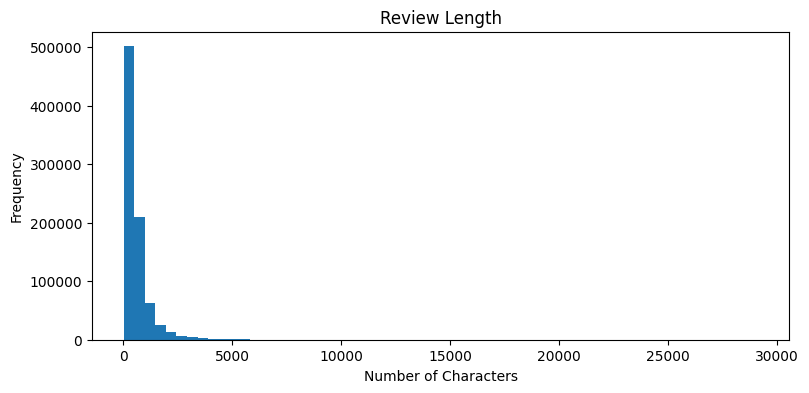

In [ ]:
plt.figure(figsize=(9, 4))
plt.hist(train_df["text_char_length"], bins=60)
plt.title("Review Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

The first chart may be hard to read because some reviews are very long.

The next chart shows reviews up to the 99th percentile.

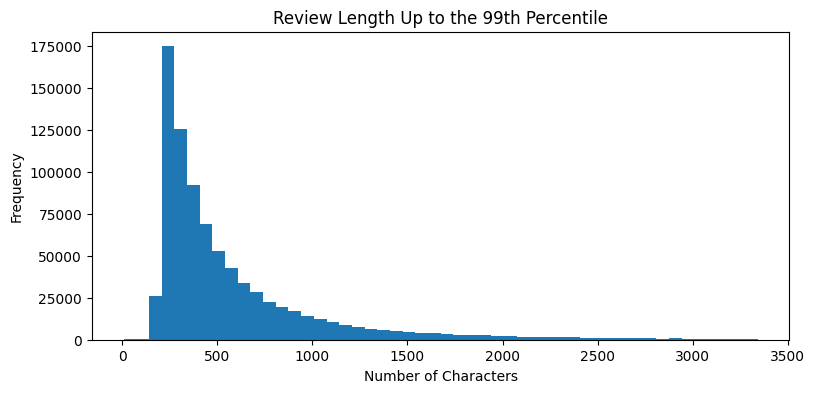

In [ ]:
char_limit = train_df["text_char_length"].quantile(0.99)

filtered_lengths = train_df.loc[
    train_df["text_char_length"] <= char_limit,
    "text_char_length"
]

plt.figure(figsize=(9, 4))
plt.hist(filtered_lengths, bins=50)
plt.title("Review Length Up to the 99th Percentile")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

In [ ]:
word_p95 = int(train_df["text_word_length"].quantile(0.95))
word_p99 = int(train_df["text_word_length"].quantile(0.99))

print("95th percentile of word count:", word_p95)
print("99th percentile of word count:", word_p99)

95th percentile of word count: 316
99th percentile of word count: 614


The review length distribution is right-skewed. Most reviews are relatively short, while a small number of reviews are very long.

The filtered histogram is more readable because it only hides the longest 1% of reviews from the chart. These reviews are not removed from the dataset.

It is useful to set a maximum input length because very long reviews increase memory use and training time.

The 95th percentile is about 1,704 characters or 316 words. The 99th percentile is about 3,344 characters or 614 words.

A reasonable first choice is to cover about 95% of the reviews. However, the final maximum input length must be selected with the tokenizer of the chosen model because word count, character count, and token count are different.

I will drop these columns to keep the shared train and split simple and not confusing

In [ ]:
train_df = train_df.drop(
    columns=["text_char_length", "text_word_length"]
)

## 14. Create the Shared Train and Validation Split

All models must use this split.

We use:

- Seed = 42
- Validation size = 20%


In [27]:
from sklearn.model_selection import StratifiedGroupKFold
text_group_ids, _ = pd.factorize(
    train_df["reviewText_clean"],
    sort=False
)

splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

train_indices, validation_indices = next(
    splitter.split(
        X=train_df,
        y=train_df["overall"],
        groups=text_group_ids
    )
)

train_clean = (
    train_df
    .iloc[train_indices]
    .reset_index(drop=True)
)

validation_clean = (
    train_df
    .iloc[validation_indices]
    .reset_index(drop=True)
)

In [28]:
print("Train shape:", train_clean.shape)
print("Validation shape:", validation_clean.shape)
print("Test shape:", test_df.shape)

Train shape: (664451, 16)
Validation shape: (166161, 16)
Test shape: (20000, 15)


In [29]:
split_check = pd.DataFrame({
    "train": train_clean["overall"].value_counts(normalize=True).sort_index(),
    "validation": validation_clean["overall"].value_counts(normalize=True).sort_index()
})

display(split_check.round(4))

,train,validation
overall,,
1,0.0993,0.0980
2,0.0675,0.0688
3,0.0969,0.0968
4,0.1873,0.1849
5,0.5491,0.5516


## 15. Final Checks
- checking for the leakage
- The test data is not used in training or model selection.

In [30]:
train_texts = set(
    train_clean["reviewText_clean"].dropna()
)

validation_texts = set(
    validation_clean["reviewText_clean"].dropna()
)

common_texts = train_texts.intersection(
    validation_texts
)

validation_common_mask = (
    validation_clean["reviewText_clean"]
    .isin(common_texts)
)

train_common_mask = (
    train_clean["reviewText_clean"]
    .isin(common_texts)
)

print(
    "commom_texts",
    len(common_texts)
)

print(
    "validatsion commom text",
    validation_common_mask.sum()
)

print(
    "validataion commom text percent: ",
    round(
        validation_common_mask.mean() * 100,
        2,
    ),
    "%"
)


commom_texts 0
validatsion commom text 0
validataion commom text percent:  0.0 %


In [31]:
assert len(train_clean) + len(validation_clean) == len(train_df)
assert train_clean["reviewText_clean"].isnull().sum() == 0
assert validation_clean["reviewText_clean"].isnull().sum() == 0
assert len(test_df) == test_df["row_id"].nunique()

print("All checks passed.")

All checks passed.


## 16. Save the Final Files

In [34]:
TRAIN_OUTPUT = OUTPUT_PATH + "/nlp_train_clean.csv"
VALIDATION_OUTPUT = OUTPUT_PATH + "/nlp_validation_clean.csv"
TEST_OUTPUT = OUTPUT_PATH + "/nlp_test_clean.csv"

train_clean.to_csv(TRAIN_OUTPUT, index=False)
validation_clean.to_csv(VALIDATION_OUTPUT, index=False)
test_df.to_csv(TEST_OUTPUT, index=False)

In [33]:
print("Saved files:")
print(TRAIN_OUTPUT)
print(VALIDATION_OUTPUT)
print(TEST_OUTPUT)

Saved files:
/content/drive/MyDrive/AI_Project2/outputs/nlp/nlp_train_clean.csv
/content/drive/MyDrive/AI_Project2/outputs/nlp/nlp_validation_clean.csv
/content/drive/MyDrive/AI_Project2/outputs/nlp/nlp_test_clean.csv


## Summary


- The target classes are imbalanced. Rating 5 contains about 55% of the samples.
- The shared split uses 80% of the data for training and 20% for validation.
- Stratification keeps the same class distribution in both parts.
- Word clouds show several common words between sentiment groups because word frequency does not represent the full sentence context.
- Most reviews are shorter than 1,704 characters or 316 words.

- The test data was not used for training or model selection.
